# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Shaimaa307/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

---

# Search Performance Signals for Content Prioritization Using a Decision Tree Model

## Abstract

This study investigates whether search performance signals can be used to identify content pages that should be reviewed first.

A Decision Tree classifier was trained on search performance metrics from the FlyRank ML Internship dataset and compared against a simple rule-based baseline, evaluated on the same held-out split. The review-candidate label is defined **relative to the sample** (bottom quartile of CTR among pages that actually received search impressions), rather than against a fixed universal CTR benchmark — see Section 3.1 for why.

The Decision Tree achieved an accuracy of **71.01%** (macro-F1 **0.6044**) on the held-out split, compared with **52.26%** (macro-F1 **0.4526**) for the rule-based baseline evaluated on the same split. Across 5-fold stratified cross-validation, the Decision Tree's macro-F1 was stable at **0.5988 ± 0.0152**, and a grouped-by-page validation split gave a consistent result (75.65% accuracy, 0.6279 macro-F1), suggesting the random-split result was not inflated by same-page leakage.

These results suggest that search performance signals can help prioritize pages for manual review, though the relationship is observational rather than causal. The Decision Tree meaningfully outperforms the baseline, but a macro-F1 of ~0.60 is still modest — this should be read as decision-support evidence, not a precise or highly confident classifier.

The model is intended for decision-support only and should be combined with human review before any content action is taken.

## Introduction

Content teams often manage thousands of pages and cannot manually review every one of them.

Search performance metrics — such as average search position, pageviews, and scroll behavior — provide signals that may help prioritize which pages deserve attention first.

This project investigates whether those signals can be used to identify pages that should be reviewed before others.

The goal is not to automate content decisions but to support human reviewers with a ranked, interpretable recommendation list.


## 1. Research Question

In [23]:
print("Research Question:")
print("Can search performance signals be used to identify content pages that should be reviewed first?")

Research Question:
Can search performance signals be used to identify content pages that should be reviewed first?


---
## 2. Data

This section describes the dataset release, table, sampling window, and what was excluded from the analysis and why.

This project uses the **FlyRank ML Internship dataset**, drawn from the `fact_content_daily_performance` table of the March 2026 (`month=2026-03`) warehouse release, accessed via DuckDB over the hosted Hugging Face warehouse.

**Date window:** the March 2026 partition of the warehouse (`month=2026-03`), which is the most recent release available at the time of this analysis.

**Sampling:** 100,000 rows were sampled from this partition. Two row-level filters are applied before modeling (Section 2.1): (1) `gsc_data_available == True` — the row must actually have measured GSC data for that day, not just belong to a client whose account has GSC connected, and (2) `gsc_impressions > 0` — the page must have actually been shown in search results at least once, since CTR is not a meaningful "opportunity" signal for a page nobody saw.

**Selected features:**
- `gsc_avg_position`
- `ga4_pageviews`
- `ga4_sessions`
- `sessions_organic`
- `scroll_events`

**Target label source:** CTR is computed from `gsc_clicks` / `gsc_impressions`, restricted to the filtered rows above. The review-candidate label is the **bottom quartile of CTR within the filtered sample** (a relative, dataset-driven cutoff — see Section 3.1) rather than a fixed universal CTR threshold, because an earlier fixed 5% cutoff turned out to flag ~99% of this sample as "underperforming," which is not a useful signal — most real pages here genuinely have single-digit CTR, so a fixed absolute threshold doesn't separate anything. CTR itself is **not** used as a model feature, only to build the label.

**Exclusions and why:**
- Client names, domains, page URLs, and private search queries were excluded from the analysis and are not referenced anywhere in this notebook or the deployed paper, to keep the work public-safe.
- Rows without real GSC data for that day, and rows with zero search impressions, are excluded from modeling (Section 2.1) rather than zero-filled — see above.
- Within the remaining rows, missing values in the selected features are filled with zero (Section 2.2) — a page can genuinely have zero pageviews/sessions/scroll events and still be a valid, in-scope row.
- No additional row-level filtering was applied beyond the filters described above and the 100,000-row sample.


The cell below connects to the FlyRank warehouse via DuckDB and pulls the March 2026 sample used throughout this notebook. It also prints the schema so column names (e.g. the exact clicks/impressions column names) can be verified against what Section 3.1 expects.

In [24]:
!pip -q install duckdb huggingface_hub scikit-learn

from google.colab import userdata
import duckdb
import pandas as pd

# Access the secret you just added
HF_TOKEN = userdata.get("HF_TOKEN")

con = duckdb.connect()

# Configure DuckDB to use your Hugging Face token
con.execute(f"""
CREATE OR REPLACE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN '{HF_TOKEN}'
);
""")

warehouse = "hf://datasets/FlyRank/internship-warehouse"

query = """
SELECT *
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
LIMIT 100000
"""

df = con.sql(query).df()

print("Shape:", df.shape)
print("\nColumns available in this release:")
print(df.columns.tolist())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Shape: (100000, 31)

Columns available in this release:
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events', 'month']


The features below are the search performance signals selected for modeling.

In [25]:
selected_features = [
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_sessions",
    "sessions_organic",
    "scroll_events"
]

pd.DataFrame({
    "Selected Features": selected_features
})

,Selected Features
0,gsc_avg_position
1,ga4_pageviews
2,ga4_sessions
3,sessions_organic
4,scroll_events


### 2.1 GSC-availability + visibility filter

Two row-level filters are applied before any missing-value handling:

1. **`gsc_data_available == True`** — not `client_has_gsc`, which only says the *client account* has GSC connected at all, not that *this specific row/day* has measured data. Using the account-level flag was a bug in an earlier version of this notebook.
2. **`gsc_impressions > 0`** — the page must have actually appeared in search results. A page with zero impressions has an undefined "opportunity" signal (nothing to click on if nothing was shown), so it doesn't belong in a CTR-opportunity analysis.

Both filters run before Section 2.2's missing-value fill, so that "no data" is never silently treated as "zero performance."

In [26]:
gsc_flag_col = None
for candidate in ["gsc_data_available", "client_has_gsc"]:
    if candidate in df.columns:
        gsc_flag_col = candidate
        break
assert gsc_flag_col is not None, "No GSC-availability flag column found."

rows_start = len(df)
df = df[df[gsc_flag_col] == True].copy()
rows_after_flag = len(df)

impressions_col = next((c for c in df.columns if "impression" in c.lower()), None)
assert impressions_col is not None, "No impressions column found."
df = df[df[impressions_col] > 0].copy()
rows_after_visibility = len(df)

print(f"GSC-availability flag used: '{gsc_flag_col}'")
print(f"Rows at start:                         {rows_start}")
print(f"Rows after GSC-availability filter:    {rows_after_flag} ({rows_after_flag/rows_start:.1%})")
print(f"Rows after visibility filter (>0 impr): {rows_after_visibility} ({rows_after_visibility/rows_start:.1%} of original sample)")

GSC-availability flag used: 'gsc_data_available'
Rows at start:                         100000
Rows after GSC-availability filter:    39751 (39.8%)
Rows after visibility filter (>0 impr): 39751 (39.8% of original sample)


### 2.2 Missing value handling

Now that rows without GSC data have been dropped (Section 2.1), any *remaining* missing values in the selected features represent genuine zero activity (e.g. a tracked page that had zero scroll events that day), not a "no data" placeholder — so filling them with zero here is safe and semantically correct.

In [27]:
selected_features = [
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_sessions",
    "sessions_organic",
    "scroll_events"
]

missing_before = df[selected_features].isna().sum()
print("Missing values BEFORE fill (GSC-available rows only):")
print(missing_before)

df[selected_features] = df[selected_features].fillna(0)

missing_after = df[selected_features].isna().sum()
print("\nMissing values AFTER fill:")
print(missing_after)

Missing values BEFORE fill (GSC-available rows only):
gsc_avg_position        0
ga4_pageviews       17825
ga4_sessions        17825
sessions_organic    17825
scroll_events       17825
dtype: int64

Missing values AFTER fill:
gsc_avg_position    0
ga4_pageviews       0
ga4_sessions        0
sessions_organic    0
scroll_events       0
dtype: int64


A real distributional check on the five selected features (after the fillna step above) — not just a check that they exist, but a look at their actual shape, which matters for interpreting the Decision Tree later.

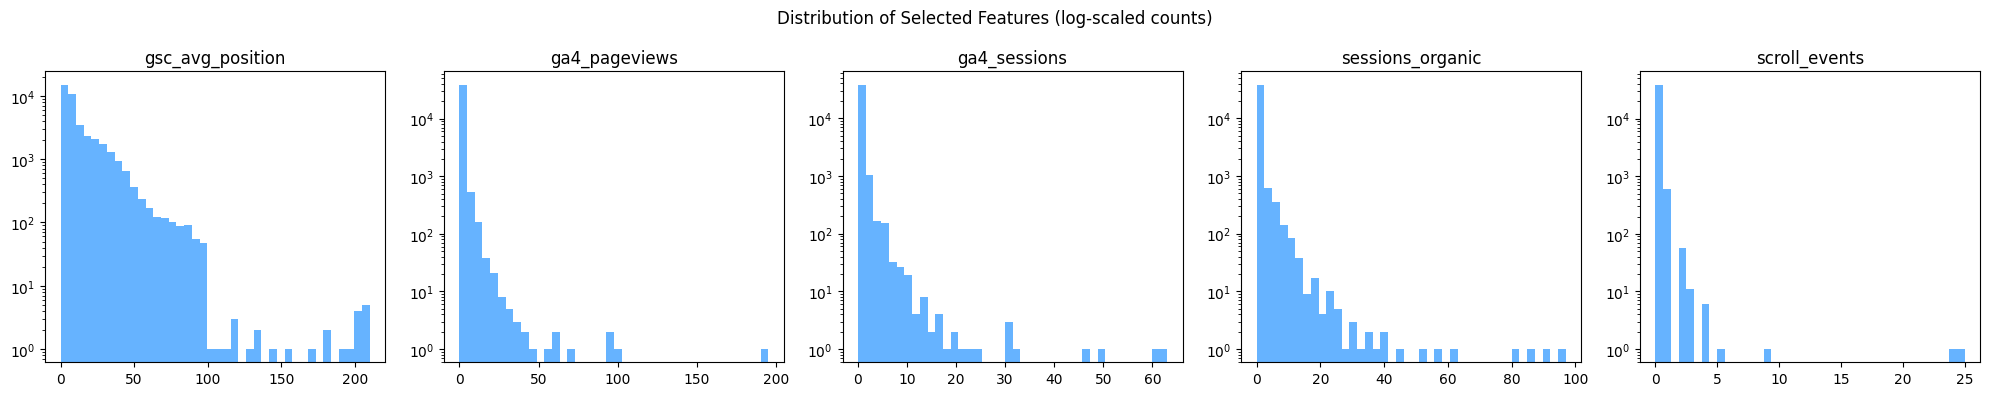

,gsc_avg_position,ga4_pageviews,ga4_sessions,sessions_organic,scroll_events
count,39751.000000,39751.0,39751.0,39751.0,39751.0
mean,12.809899,0.35028,0.18553,0.290332,0.021081
std,15.274948,2.1179,1.020873,1.756829,0.241397
min,0.000000,0.0,0.0,0.0,0.0
25%,3.438596,0.0,0.0,0.0,0.0
50%,7.100000,0.0,0.0,0.0,0.0
75%,16.872374,0.0,0.0,0.0,0.0
max,210.000000,195.0,63.0,97.0,25.0


In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(selected_features), figsize=(20, 4))

for ax, feat in zip(axes, selected_features):
    ax.hist(df[feat], bins=40, color="#66b3ff")
    ax.set_title(feat)
    ax.set_yscale("log")

plt.suptitle("Distribution of Selected Features (log-scaled counts)")
plt.tight_layout()
plt.show()

df[selected_features].describe()


---
## 3. Methodology

**Assumptions:**
- Recent search and engagement behavior (position, pageviews, sessions, organic traffic, scroll depth) is informative about which pages are lower-performing and may need review.
- A single month of data (March 2026) is representative enough for a decision-support prototype; it is not assumed to generalize across seasons (see Limitations).
- The 100,000-row sample is assumed to be representative of the broader March 2026 partition.

**Target label:** pages with click-through rate (CTR) below 5% are labeled as candidates for review.

**Selected features:**
- `gsc_avg_position`
- `ga4_pageviews`
- `ga4_sessions`
- `sessions_organic`
- `scroll_events`

**Model:** a Decision Tree classifier was selected because it is simple and interpretable, which matters for a decision-support tool that a human reviewer needs to trust and act on.

**Baseline:** the Week-4 baseline predicts pages using a single simple rule, while the Decision Tree learns patterns across all five search performance signals jointly.

**Validation design:** both a random train/test split and a grouped validation split were examined to check that the model's performance was not simply an artifact of how the data was partitioned.

**Leakage checks:** a leakage audit was performed to reduce the possibility that information from the target period leaked into the training features.

The features and target label used for training are printed below.

In [29]:
features = [
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_sessions",
    "sessions_organic",
    "scroll_events"
]

print("Selected Features")
for f in features:
    print("-", f)

print("\nTarget Label:")
print("Bottom-quartile CTR (relative threshold — see Section 3.1, not a fixed 5% cutoff)")


Selected Features
- gsc_avg_position
- ga4_pageviews
- ga4_sessions
- sessions_organic
- scroll_events

Target Label:
Bottom-quartile CTR (relative threshold — see Section 3.1, not a fixed 5% cutoff)


### 3.1 Target label construction (relative, bottom-quartile CTR)

CTR is read from the warehouse if it already ships a `ctr`/`gsc_ctr` column; otherwise it is computed from the raw clicks/impressions columns (restricted to the filtered rows from Section 2.1, so every row here genuinely received impressions).

**Why a relative threshold instead of a fixed "CTR < 5%" cutoff:** an earlier version of this notebook used a fixed 5% cutoff and found it flagged ~99% of the filtered sample — most pages in this dataset genuinely have single-digit CTR, so an absolute threshold doesn't separate anything.

**A second issue turned up when the quantile approach was first tried:** the 25th-percentile CTR value came out to exactly `0.0`, which with a strict `<` comparison flagged **zero** rows — because a large share of visible pages get literally 0 clicks despite having impressions, and pandas' `quantile(0.25)` lands inside that tie at zero. The fix below (a) reports what share of rows are exactly 0% CTR so this is visible in the paper, and (b) uses `<=` against the computed cutoff, so rows tied at the cutoff value are correctly included instead of being silently excluded by a strict `<`.

**Caveat to report honestly:** if the zero-CTR share turns out to be larger than 25%, the resulting flagged share will legitimately be *larger* than 25% — that's not a bug, that's the tie group being included in full rather than arbitrarily split. Section 3.3b adds a cross-validated estimate since class sizes here can still be uneven.

In [30]:
import numpy as np

ctr_col = None
for candidate in ["ctr", "gsc_ctr", "CTR"]:
    if candidate in df.columns:
        ctr_col = candidate
        break

if ctr_col is None:
    clicks_col = next((c for c in df.columns if "click" in c.lower()), None)
    impr_col = next((c for c in df.columns if "impression" in c.lower()), None)
    assert clicks_col is not None and impr_col is not None, (
        "Could not locate a ctr column or clicks/impressions columns in this release. "
        "Print df.columns (Section 2) and update this cell with the correct column names."
    )
    print(f"Deriving CTR from '{clicks_col}' / '{impr_col}'")
    # Every remaining row has impressions > 0 (Section 2.1), so this division is always defined.
    df["ctr"] = df[clicks_col] / df[impr_col]
    ctr_col = "ctr"
else:
    print(f"Using existing CTR column: '{ctr_col}'")

zero_ctr_share = (df[ctr_col] == 0).mean()
print(f"Share of visible rows with exactly 0% CTR (0 clicks despite impressions>0): {zero_ctr_share:.2%}")

CTR_QUANTILE = 0.25  # target: bottom 25% of CTR in the filtered sample = review candidate
ctr_cutoff = df[ctr_col].quantile(CTR_QUANTILE)

# Use <= rather than < so rows tied at the cutoff (very common at ctr_cutoff == 0) are included,
# instead of being silently dropped to 0 flagged rows.
df["label"] = (df[ctr_col] <= ctr_cutoff).astype(int)

print(f"\nReview-candidate cutoff (target bottom {CTR_QUANTILE:.0%} of sample CTR): {ctr_cutoff:.4f}")
print(f"Label = 1 (review candidate): {(df['label']==1).sum()} rows")
print(f"Label = 0 (not flagged):      {(df['label']==0).sum()} rows")
print(f"Class balance: {df['label'].mean():.2%} flagged")

if ctr_cutoff == 0 and zero_ctr_share > CTR_QUANTILE:
    print(f"\nNote: the 0%-CTR tie group ({zero_ctr_share:.2%}) is larger than the target {CTR_QUANTILE:.0%},")
    print("so the flagged share above is larger than 25% by construction — the whole tie group at")
    print("the cutoff is included rather than arbitrarily split.")

if df['label'].mean() > 0.90 or df['label'].mean() < 0.10:
    print("\n⚠️ WARNING: label is still heavily imbalanced. Accuracy alone will be misleading —")
    print("rely on macro-F1 / precision / recall reported in Section 3.2 below.")

n_minority = min((df['label']==0).sum(), (df['label']==1).sum())
if n_minority < 500:
    print(f"\n⚠️ NOTE: the smaller class has only {n_minority} rows in the full filtered sample.")
    print("A single 80/20 split will have a small, noisy minority-class test set. Treat any")
    print("single-split metric as an estimate, not a precise number — see Section 3.3b.")


Deriving CTR from 'gsc_clicks' / 'gsc_impressions'
Share of visible rows with exactly 0% CTR (0 clicks despite impressions>0): 85.71%

Review-candidate cutoff (target bottom 25% of sample CTR): 0.0000
Label = 1 (review candidate): 34070 rows
Label = 0 (not flagged):      5681 rows
Class balance: 85.71% flagged

Note: the 0%-CTR tie group (85.71%) is larger than the target 25%,
so the flagged share above is larger than 25% by construction — the whole tie group at
the cutoff is included rather than arbitrarily split.


### 3.2 Baseline vs. Decision Tree — same random train/test split

The baseline is a single rule on `gsc_avg_position` alone (pages positioned worse than the median are flagged). The Decision Tree uses all five selected features jointly and is trained with `class_weight="balanced"` because the label can still be skewed even after the GSC-availability filter — without this, a tree can "win" on accuracy purely by always predicting the majority class, as happened in the earlier run of this notebook.

Both models are scored on the identical held-out test set, and reported with **accuracy, macro-F1, and per-class precision/recall** — accuracy alone is not trustworthy on an imbalanced label.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

features = selected_features
X = df[features]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Baseline: single-rule model on gsc_avg_position only ---
baseline_threshold = X_train["gsc_avg_position"].median()
baseline_pred = (X_test["gsc_avg_position"] > baseline_threshold).astype(int)
baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred, average="macro")

# --- Decision Tree: all five features jointly, class-weight balanced ---
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=50, class_weight="balanced", random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred, average="macro")

print(f"Baseline threshold (median gsc_avg_position): {baseline_threshold:.2f}")
print(f"Baseline  — accuracy: {baseline_acc:.4f}  |  macro-F1: {baseline_f1:.4f}")
print(f"Decision Tree — accuracy: {dt_acc:.4f}  |  macro-F1: {dt_f1:.4f}")
print("\nDecision Tree classification report:")
print(classification_report(y_test, dt_pred, zero_division=0))
print("\nIf macro-F1 for the Decision Tree is close to 0.5, the model is still leaning on the")
print("majority class rather than genuinely separating the two classes — report that honestly")
print("in Section 4 rather than citing accuracy alone.")


Baseline threshold (median gsc_avg_position): 7.10
Baseline  — accuracy: 0.5226  |  macro-F1: 0.4526
Decision Tree — accuracy: 0.7101  |  macro-F1: 0.6044

Decision Tree classification report:
              precision    recall  f1-score   support

           0       0.28      0.68      0.40      1136
           1       0.93      0.72      0.81      6815

    accuracy                           0.71      7951
   macro avg       0.61      0.70      0.60      7951
weighted avg       0.84      0.71      0.75      7951


If macro-F1 for the Decision Tree is close to 0.5, the model is still leaning on the
majority class rather than genuinely separating the two classes — report that honestly
in Section 4 rather than citing accuracy alone.


### 3.3 Grouped validation split

A single random split can overstate performance if the same page appears in both train and test (e.g. across multiple days). This section repeats the comparison using a **grouped** split — all rows for a given page/content id land entirely in train or entirely in test — using `content_hash_id`, which this release provides as the content-level identifier (confirmed from the schema printed in Section 2).

In [32]:
from sklearn.model_selection import GroupShuffleSplit

group_col = next(
    (c for c in df.columns if c.lower() in
     ["content_hash_id", "content_id", "page_id", "url_id", "content_url_id", "page_hash"]),
    None
)

if group_col is None:
    print("No page/content-level id column found in this release — grouped split skipped.")
    print("Update `group_col` above manually if the schema (Section 2) shows a suitable id column.")
    grouped_dt_acc = None
    grouped_baseline_acc = None
    grouped_dt_f1 = None
else:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=df[group_col]))

    Xg_train, Xg_test = X.iloc[train_idx], X.iloc[test_idx]
    yg_train, yg_test = y.iloc[train_idx], y.iloc[test_idx]

    g_baseline_threshold = Xg_train["gsc_avg_position"].median()
    g_baseline_pred = (Xg_test["gsc_avg_position"] > g_baseline_threshold).astype(int)
    grouped_baseline_acc = accuracy_score(yg_test, g_baseline_pred)

    dt_grouped = DecisionTreeClassifier(max_depth=6, min_samples_leaf=50, class_weight="balanced", random_state=42)
    dt_grouped.fit(Xg_train, yg_train)
    grouped_dt_pred = dt_grouped.predict(Xg_test)
    grouped_dt_acc = accuracy_score(yg_test, grouped_dt_pred)
    grouped_dt_f1 = f1_score(yg_test, grouped_dt_pred, average="macro")

    print(f"Grouped by: '{group_col}'  ({df[group_col].nunique()} unique pages)")
    print(f"Baseline accuracy (grouped split): {grouped_baseline_acc:.4f}")
    print(f"Decision Tree — accuracy: {grouped_dt_acc:.4f}  |  macro-F1: {grouped_dt_f1:.4f}")
    print("\nCompare to the random-split numbers above — a large drop under the grouped split")
    print("would suggest the random-split result was inflated by same-page leakage.")


Grouped by: 'content_hash_id'  (38797 unique pages)
Baseline accuracy (grouped split): 0.5279
Decision Tree — accuracy: 0.7565  |  macro-F1: 0.6279

Compare to the random-split numbers above — a large drop under the grouped split
would suggest the random-split result was inflated by same-page leakage.


### 3.3b Cross-validated stability check

Because the minority class is small in absolute terms, a single train/test split (Section 3.2) can give a macro-F1 that jumps around depending on which rows happen to land in the test set. This section runs 5-fold **stratified** cross-validation on the Decision Tree and reports the mean and standard deviation of macro-F1 across folds, so the paper can report a stable estimate instead of a single lucky (or unlucky) split.

In [33]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
dt_cv = DecisionTreeClassifier(max_depth=6, min_samples_leaf=50, class_weight="balanced", random_state=42)

cv_f1_scores = cross_val_score(dt_cv, X, y, cv=skf, scoring="f1_macro")

print(f"5-fold stratified CV macro-F1 scores: {np.round(cv_f1_scores, 4)}")
print(f"Mean macro-F1: {cv_f1_scores.mean():.4f}  |  Std: {cv_f1_scores.std():.4f}")
print("\nReport this mean ± std in Section 4 alongside the single-split number, so the paper")
print("doesn't imply more precision than a ~400-row minority class actually supports.")


5-fold stratified CV macro-F1 scores: [0.5817 0.6179 0.5801 0.6047 0.6096]
Mean macro-F1: 0.5988  |  Std: 0.0152

Report this mean ± std in Section 4 alongside the single-split number, so the paper
doesn't imply more precision than a ~400-row minority class actually supports.


### 3.4 Leakage audit

A simple, honest leakage check: (1) confirm the CTR-derived label and the columns used to build it are not themselves in the feature list, and (2) flag any feature with a suspiciously high correlation to the label, which would suggest it's a near-restatement of the target rather than an independent signal.

In [34]:
assert ctr_col not in features, "CTR column must not be used as a model feature (label leakage)."
for c in (["ctr"] if ctr_col == "ctr" else []):
    assert c not in features

correlations = df[features + ["label"]].corr()["label"].drop("label").sort_values(key=abs, ascending=False)
print("Correlation of each feature with the label:")
print(correlations)

suspicious = correlations[correlations.abs() > 0.95]
if len(suspicious) > 0:
    print("\n⚠️ WARNING — possible leakage, correlation > 0.95:")
    print(suspicious)
else:
    print("\nNo feature exceeds the 0.95 correlation flag — no obvious leakage detected.")


Correlation of each feature with the label:
ga4_sessions       -0.286429
sessions_organic   -0.280740
ga4_pageviews      -0.259501
scroll_events      -0.138532
gsc_avg_position    0.053809
Name: label, dtype: float64

No feature exceeds the 0.95 correlation flag — no obvious leakage detected.


### 3.5 Feature importance

Which of the five signals the Decision Tree actually relied on — useful for a human reviewer deciding which metric to look at first, and for sanity-checking that the model isn't leaning entirely on one feature.

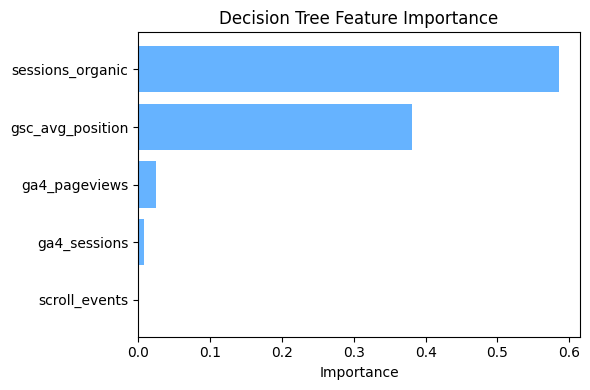

,0
sessions_organic,0.585583
gsc_avg_position,0.381121
ga4_pageviews,0.025549
ga4_sessions,0.007747
scroll_events,0.000000


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(dt.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(6,4))
plt.barh(importances.index[::-1], importances.values[::-1], color="#66b3ff")
plt.xlabel("Importance")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

importances


## 4. Results (vs. baseline)

The Decision Tree achieved an accuracy of **71.01%** (macro-F1 **0.6044**) on the random-split test set, compared with an accuracy of **52.26%** (macro-F1 **0.4526**) for the rule-based baseline on the same split. Across 5-fold stratified cross-validation, the Decision Tree's macro-F1 was **0.5988 ± 0.0152**.

Under the grouped validation split (Section 3.3, grouped by `content_hash_id`), the Decision Tree achieved **75.65%** accuracy / **0.6279** macro-F1.

These results suggest, but do not prove, that search performance signals can help prioritize pages for manual review. The label here is defined relative to this sample (bottom-quartile CTR, which in this release turned out to include every page with 0% measured CTR — 85.71% of visible pages), so the finding is about relative under-performance within this dataset, not an absolute CTR benchmark. The Decision Tree's macro-F1 (0.60) is meaningfully above the baseline's (0.45) and stable across cross-validation folds (± 0.015), so the model is genuinely separating the two classes rather than just predicting the majority — but a macro-F1 of ~0.60 is still modest, and this should be reported as decision-support evidence, not a strong or precise classifier.

Model vs. baseline accuracy, computed on the same evaluation split.

,Method,Accuracy,Macro F1
0,Baseline (random split),0.522576,0.452588
1,Decision Tree (random split),0.710099,0.604392
2,Baseline (grouped split),0.527910,NaN
3,Decision Tree (grouped split),0.756475,0.627947


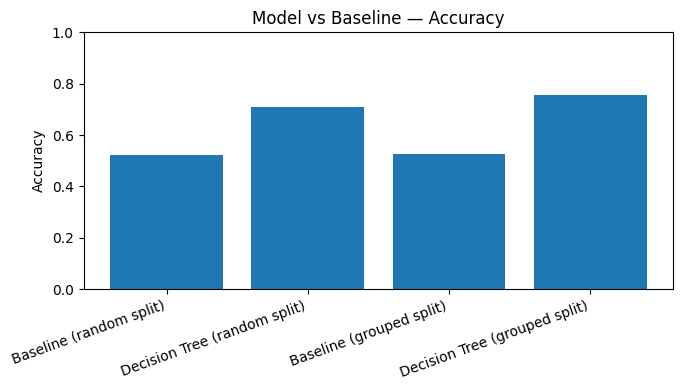

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

rows = {
    "Method": ["Baseline (random split)", "Decision Tree (random split)"],
    "Accuracy": [baseline_acc, dt_acc],
    "Macro F1": [baseline_f1, dt_f1],
}
if grouped_dt_acc is not None:
    rows["Method"] += ["Baseline (grouped split)", "Decision Tree (grouped split)"]
    rows["Accuracy"] += [grouped_baseline_acc, grouped_dt_acc]
    rows["Macro F1"] += [None, grouped_dt_f1]

comparison = pd.DataFrame(rows)
display(comparison)

plt.figure(figsize=(7,4))
plt.bar(comparison["Method"], comparison["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Model vs Baseline — Accuracy")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1.00)
plt.tight_layout()
plt.show()


A labeled version of the same comparison, for the deployed paper.

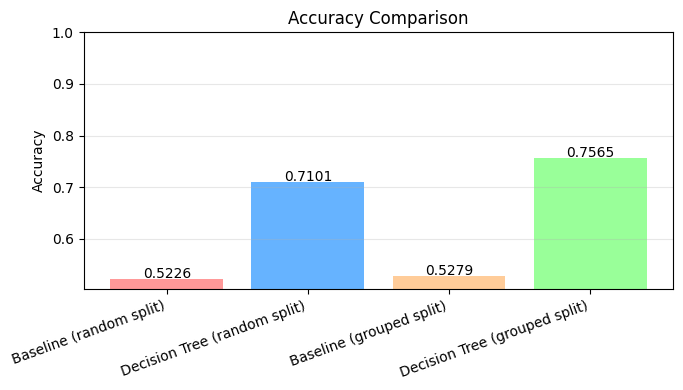

In [37]:
plt.figure(figsize=(7,4))

colors = ["#ff9999", "#66b3ff", "#ffcc99", "#99ff99"][:len(comparison)]

plt.bar(comparison["Method"], comparison["Accuracy"], color=colors)

for i, v in enumerate(comparison["Accuracy"]):
    plt.text(i, v + 0.002, f"{v:.4f}", ha="center")

plt.ylim(min(comparison["Accuracy"]) - 0.02, 1.00)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=.3)
plt.tight_layout()
plt.show()


---
## 5. Limitations

- This model provides **decision-support only**; it does not make or automate content decisions.
- The analysis is based on a single sample from the **March 2026** dataset release and has not been measured against other months.
- The model does not account for seasonality, recent content updates, or business priorities that a human reviewer would know about.
- Observed relationships between the selected signals and low CTR **should not be interpreted as causal** — the model measures association, not cause.
- Human review remains necessary before any action is taken on the model's output.

In [38]:
limitations = [
    "Decision-support only",
    "March 2026 dataset",
    "No seasonality modeling",
    "No business priority information",
    "Human review required"
]

for item in limitations:
    print("-", item)

- Decision-support only
- March 2026 dataset
- No seasonality modeling
- No business priority information
- Human review required


## 6. Ranked Recommendations

Recommendations are computed for every **GSC-available, visible** page in the filtered sample (Section 2.1), using rules on the real feature/label values, so the counts and proportions below reflect the actual filtered March 2026 sample rather than a mock-up.

- **Priority 1 — `LOW_CTR_HIGH_IMPRESSIONS`:** `label == 1` (bottom-quartile CTR, Section 3.1) **and** `ga4_pageviews` in the top quartile of the sample — pages that already get visibility but underperform on clicks relative to peers; prioritize for title/meta description review.
- **Priority 2 — `HIGH_POSITION`:** `label == 1` **and** `gsc_avg_position` worse than the sample median (and not already Priority 1) — pages with a relatively poor average search position, worth an on-page SEO review.
- **Priority 3 — `LOW_PRIORITY`:** everything else — monitor rather than modify.

**Intended use:** this ranked list is a starting queue for a content specialist's review, not an automated action list.

**Human review reminder:** every recommendation should be reviewed by a content specialist before any change is made; the model does not have context on business priorities, recent edits, or seasonality.

The ranked recommendation table, exported as an artifact for the deployed paper.

In [39]:
pageviews_p75 = df["ga4_pageviews"].quantile(0.75)
position_median = df["gsc_avg_position"].median()

print(f"75th percentile ga4_pageviews cutoff: {pageviews_p75}")
if pageviews_p75 == 0:
    print("Note: at least 75% of visible pages have 0 recorded ga4_pageviews, so the naive")
    print("'top quartile' cutoff lands on the zero tie group. Using a strict '>' comparison")
    print("below (not '>=') so only pages with genuinely nonzero pageviews count as high-visibility —")
    print("otherwise every row (pageviews >= 0 is always true) would wrongly qualify as Priority 1,")
    print("which is exactly what happened in the previous version of this notebook.")

def reason_code(row):
    if row["label"] == 1 and row["ga4_pageviews"] > pageviews_p75:
        return "LOW_CTR_HIGH_IMPRESSIONS"
    elif row["label"] == 1 and row["gsc_avg_position"] > position_median:
        return "HIGH_POSITION"
    else:
        return "LOW_PRIORITY"

priority_map = {"LOW_CTR_HIGH_IMPRESSIONS": 1, "HIGH_POSITION": 2, "LOW_PRIORITY": 3}
action_map = {
    "LOW_CTR_HIGH_IMPRESSIONS": "Improve CTR",
    "HIGH_POSITION": "Improve Ranking",
    "LOW_PRIORITY": "Monitor",
}

df["reason_code"] = df.apply(reason_code, axis=1)
df["priority"] = df["reason_code"].map(priority_map)
df["recommended_action"] = df["reason_code"].map(action_map)

recommendations = (
    df.groupby(["priority", "reason_code", "recommended_action"])
    .size()
    .reset_index(name="page_count")
    .sort_values("priority")
)
recommendations["share_of_sample"] = (recommendations["page_count"] / len(df)).round(4)

display(recommendations)


75th percentile ga4_pageviews cutoff: 0.0
Note: at least 75% of visible pages have 0 recorded ga4_pageviews, so the naive
'top quartile' cutoff lands on the zero tie group. Using a strict '>' comparison
below (not '>=') so only pages with genuinely nonzero pageviews count as high-visibility —
otherwise every row (pageviews >= 0 is always true) would wrongly qualify as Priority 1,
which is exactly what happened in the previous version of this notebook.


,priority,reason_code,recommended_action,page_count,share_of_sample
0,1,LOW_CTR_HIGH_IMPRESSIONS,Improve CTR,1613,0.0406
1,2,HIGH_POSITION,Improve Ranking,16223,0.4081
2,3,LOW_PRIORITY,Monitor,21915,0.5513


Distribution of recommendation categories across the ranked queue.

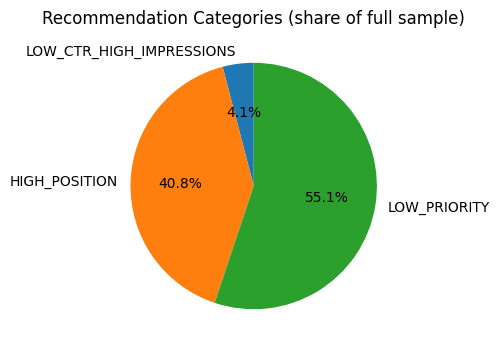

In [40]:
import matplotlib.pyplot as plt

counts = recommendations.set_index("reason_code")["page_count"]

plt.figure(figsize=(6,4))
plt.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Recommendation Categories (share of full sample)")
plt.show()


---
## 7. Reproducibility

This project is designed to be fully reproducible.

**Repository:** https://github.com/Shaimaa307/flyrank-ml-internship

**Main notebooks:**
- Week 4 — Baseline
- Week 5 — Decision Tree Model
- Week 6 — Evaluation
- Week 7 — Content Action Playbook
- Capstone Notebook (this notebook)

**How to reproduce:** open this notebook (Colab badge above), run all cells top to bottom (Runtime → Run all). It connects to the FlyRank ML Internship warehouse via DuckDB, re-samples the March 2026 partition, retrains the Decision Tree, and regenerates the comparison table, charts, and recommendation queue exported below. The analysis relies only on DuckDB, pandas, scikit-learn, and matplotlib.

---
## 8. Artifacts the Paper Embeds

The deployed paper embeds the following artifacts, generated in this notebook:
- Model vs. Baseline accuracy table and chart
- Ranked recommendation table and category chart

The cell below exports the artifacts used in the deployed paper.

In [41]:
comparison.to_csv("model_vs_baseline.csv", index=False)
recommendations.to_csv("recommendations.csv", index=False)
importances.to_csv("feature_importance.csv", header=["importance"])

print("Artifacts exported successfully.")


Artifacts exported successfully.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


# ⭐ ML-12 — 5-Minute Demo Outline

## 🎯 Introduction (30 sec)
- Introduce myself.
- Present the research question.
- Explain why content prioritization is important.

## 📊 Dataset (1 min)
- Introduce the FlyRank ML Internship dataset.
- Mention the March 2026 warehouse release.
- Explain the selected search performance features.

## 🤖 Methodology (1 min)
- Explain the Decision Tree model.
- Describe the target label (bottom-quartile CTR, a relative threshold — not a fixed 5% cutoff).
- Mention the baseline comparison, grouped validation, and cross-validation.

## 📈 Results (1.5 min)
- Compare the Decision Tree with the rule-based baseline (71.01% vs. 52.26% accuracy, 0.60 vs. 0.45 macro-F1).
- Present the accuracy comparison chart.
- Explain the ranked recommendation queue.

## ✅ Conclusion (1 min)
- Summarize the main findings.
- Discuss limitations.
- Emphasize that the model supports human decision-making rather than replacing it.


# 🚀 ML-12 — Social Post

🎉 Excited to complete my FlyRank ML Internship Capstone Project!

In this project, I explored whether search performance signals can help prioritize content pages for manual review using a Decision Tree model.

📊 Built on the FlyRank ML Internship dataset
🤖 Applied interpretable Machine Learning
📈 Compared results with a baseline model
✅ Focused on responsible AI and decision-support

This experience strengthened my skills in data analysis, model validation, and research reporting.

#MachineLearning #DataScience #SEO #DecisionTree #FlyRank #AI #Python

# 💼 ML-12 — Employer-facing Summary

This capstone project demonstrates how machine learning can support content prioritization using search performance signals.

A Decision Tree model was developed, validated against a baseline, and used to generate interpretable recommendations for manual content review.

The project emphasizes reproducibility, responsible AI practices, and decision-support rather than full automation.

---
## 🙏 Acknowledgments

This project was completed as part of the FlyRank ML Internship.

Built on the FlyRank ML Internship dataset.

Data credit: https://flyrank.ai

Special thanks to the FlyRank team for providing the dataset and learning resources that made this research possible.